# Training - version 2 hyperparameters

**In:** `data/split` (frozen by model selection)  
**Out:** MLflow run tagged `version=v2` - the tuned candidate

| Step | What |
| --- | --- |
| 1 | Load the frozen split |
| 2 | Candidate grid |
| 3 | Sweep, ranked on validation |
| 4 | Refit the winner as v2 |
| 5 | Predicted vs actual |

**The grid is ranked on validation (2022), never on test.** Choosing
hyperparameters by test score leaks the test set and makes the evaluation number
meaningless. Test is scored once, for the winner only.

v1 under-predicts badly at high demand - at actual 11+ departures/hour it
predicts about a third of the truth. Several candidates below target that
directly: more leaves and smaller leaf minimums give the model room to fit busy
station-hours instead of regressing them toward the mean.

Comparing versions happens in evaluation, not here.

## Step 1 - Load the frozen split

In [23]:
import json
import os
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SPLIT = Path("/opt/data/ml/split")

contract = json.loads((SPLIT / "split.json").read_text())
TARGET = contract["target"]
FEATURES = contract["features"]
PEAK_HOURS = contract["peak_hours"]

train = pd.read_parquet(SPLIT / "train.parquet")
val = pd.read_parquet(SPLIT / "val.parquet")
test = pd.read_parquet(SPLIT / "test.parquet")

assert train["start_date"].max() < val["start_date"].min(), "train/val overlap"
assert val["start_date"].max() < test["start_date"].min(), "val/test overlap"
assert set(FEATURES).issubset(train.columns), "split is missing a contracted feature"

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("bike-demand")

for name, df in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:6} {len(df):>9,} rows  "
          f"{df['start_date'].min().date()} .. {df['start_date'].max().date()}")
print(f"\n{len(FEATURES)} features -> {TARGET}")

train  1,999,104 rows  2019-01-01 .. 2021-12-31
val      611,040 rows  2022-01-01 .. 2022-12-31
test     665,760 rows  2023-01-01 .. 2023-12-31

15 features -> trip_count


In [24]:
def score(y_true, y_pred, hours):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    y_true = np.asarray(y_true, dtype=float)
    peak = np.isin(hours, PEAK_HOURS)
    busy = y_true >= 11  # where v1 fails; tracked so tuning is judged on it too
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE_peak": mean_absolute_error(y_true[peak], y_pred[peak]),
        "MAE_offpeak": mean_absolute_error(y_true[~peak], y_pred[~peak]),
        "MAE_busy": mean_absolute_error(y_true[busy], y_pred[busy]),
    }


def build(params):
    """season is the only string column; the rest pass through as numerics."""
    return Pipeline([
        ("prep", ColumnTransformer(
            [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
              ["season"])],
            remainder="passthrough",
        )),
        ("model", HistGradientBoostingRegressor(**params)),
    ])


DATA_CONTEXT = {
    "rows_train": len(train),
    "rows_val": len(val),
    "rows_test": len(test),
    "n_stations": train["station_id"].nunique(),
    "train_years": str(contract["train_years"]),
    "val_years": str(contract["val_years"]),
    "test_years": str(contract["test_years"]),
    "features": ",".join(FEATURES),
}

print(f"{len(FEATURES)} features -> {TARGET}")

15 features -> trip_count


## Step 2 - Candidate grid

Ten candidates. Three groups:

- **capacity** - more leaves, so busy station-hours get their own splits
- **pace** - slower learning with more trees, the usual accuracy trade
- **leaf size** - smaller `min_samples_leaf` lets rare high-demand hours survive
  as their own leaves instead of being averaged into quiet ones

`early_stopping` stays off throughout: sklearn's internal holdout is drawn at
random, which leaks across time on a chronological split.

In [25]:
BASE = {"loss": "poisson", "early_stopping": False, "random_state": 0}
V1 = {"learning_rate": 0.1, "max_leaf_nodes": 31, "max_iter": 300,
      "min_samples_leaf": 20, "l2_regularization": 0.0}

GRID = [
    V1,                                                                  # 0 reference
    {**V1, "max_leaf_nodes": 63},                                        # 1 capacity
    {**V1, "max_leaf_nodes": 127},                                       # 2
    {**V1, "max_leaf_nodes": 255},                                       # 3
    {**V1, "learning_rate": 0.05, "max_leaf_nodes": 127, "max_iter": 600},  # 4 pace
    {**V1, "learning_rate": 0.05, "max_leaf_nodes": 255, "max_iter": 600},  # 5
    {**V1, "learning_rate": 0.03, "max_leaf_nodes": 255, "max_iter": 900},  # 6
    {**V1, "max_leaf_nodes": 255, "min_samples_leaf": 5},                # 7 leaf size
    {**V1, "learning_rate": 0.05, "max_leaf_nodes": 255, "max_iter": 600,
     "min_samples_leaf": 5},                                             # 8
    {**V1, "learning_rate": 0.05, "max_leaf_nodes": 255, "max_iter": 600,
     "min_samples_leaf": 5, "l2_regularization": 1.0},                   # 9
]

print(f"{len(GRID)} candidates")
pd.DataFrame(GRID)

10 candidates


,learning_rate,max_leaf_nodes,max_iter,min_samples_leaf,l2_regularization
0,0.10,31,300,20,0.0
1,0.10,63,300,20,0.0
2,0.10,127,300,20,0.0
3,0.10,255,300,20,0.0
4,0.05,127,600,20,0.0
5,0.05,255,600,20,0.0
6,0.03,255,900,20,0.0
7,0.10,255,300,5,0.0
8,0.05,255,600,5,0.0
9,0.05,255,600,5,1.0


## Step 3 - Sweep

One nested MLflow run per candidate under a single parent, so the search reads
as one unit rather than ten loose runs.

In [26]:
%%time
results = []

with mlflow.start_run(run_name="v2_grid_search"):
    mlflow.set_tags({"model": "hist_gbm", "version": "v2_search", **DATA_CONTEXT})
    mlflow.log_param("n_candidates", len(GRID))

    for i, overrides in enumerate(GRID):
        params = {**BASE, **overrides}
        with mlflow.start_run(run_name=f"cand_{i:02d}", nested=True):
            mlflow.log_params(params)
            candidate = build(params)
            candidate.fit(train[FEATURES], train[TARGET])

            # validation only - test stays sealed until the winner is chosen
            s = score(val[TARGET], candidate.predict(val[FEATURES]), val["hour"])
            mlflow.log_metrics({f"val_{k}": v for k, v in s.items()})

        results.append({**overrides, **{f"val_{k}": v for k, v in s.items()}})
        print(f"cand_{i:02d}  val MAE {s['MAE']:.4f}  busy {s['MAE_busy']:.3f}")

leaderboard = pd.DataFrame(results).sort_values("val_MAE").reset_index(drop=True)
print(f"\nbest val MAE {leaderboard.loc[0, 'val_MAE']:.4f}")

🏃 View run cand_00 at: http://mlflow:5000/#/experiments/1/runs/2ee994aae1114f3dbf71cbf910e309fa
🧪 View experiment at: http://mlflow:5000/#/experiments/1
cand_00  val MAE 1.4081  busy 8.614
🏃 View run cand_01 at: http://mlflow:5000/#/experiments/1/runs/d0db3cff862b43a29dd612c422371c3d
🧪 View experiment at: http://mlflow:5000/#/experiments/1
cand_01  val MAE 1.4036  busy 8.452
🏃 View run cand_02 at: http://mlflow:5000/#/experiments/1/runs/8e9dde78b7d84c0c81de440d8c689b52
🧪 View experiment at: http://mlflow:5000/#/experiments/1
cand_02  val MAE 1.4027  busy 8.382
🏃 View run cand_03 at: http://mlflow:5000/#/experiments/1/runs/4de9e243d9be44dbbcf9d3a02d33c74a
🧪 View experiment at: http://mlflow:5000/#/experiments/1
cand_03  val MAE 1.4044  busy 8.342
🏃 View run cand_04 at: http://mlflow:5000/#/experiments/1/runs/2d4c6911ee1740e089e263c256e8f2a5
🧪 View experiment at: http://mlflow:5000/#/experiments/1
cand_04  val MAE 1.4028  busy 8.359
🏃 View run cand_05 at: http://mlflow:5000/#/experiments

In [27]:
leaderboard

,learning_rate,max_leaf_nodes,max_iter,min_samples_leaf,l2_regularization,val_MAE,val_RMSE,val_MAE_peak,val_MAE_offpeak,val_MAE_busy
0,0.10,127,300,20,0.0,1.402697,2.578314,2.007497,1.153661,8.382200
1,0.05,127,600,20,0.0,1.402845,2.575893,2.009190,1.153173,8.358807
2,0.05,255,600,5,1.0,1.403231,2.580280,2.009708,1.153505,8.295419
3,0.03,255,900,20,0.0,1.403402,2.579735,2.009939,1.153651,8.299043
4,0.05,255,600,20,0.0,1.403408,2.581745,2.009417,1.153875,8.303569
5,0.05,255,600,5,0.0,1.403489,2.581317,2.010477,1.153553,8.312933
6,0.10,63,300,20,0.0,1.403613,2.575033,2.007702,1.154870,8.452457
7,0.10,255,300,20,0.0,1.404353,2.586555,2.013498,1.153528,8.342401
8,0.10,255,300,5,0.0,1.404801,2.589363,2.013296,1.154244,8.343482
9,0.10,31,300,20,0.0,1.408149,2.581822,2.007490,1.161361,8.614160


## Step 4 - Refit the winner as v2

The winning configuration is retrained and scored on test - the first and only
time the test set is touched here.

In [28]:
%%time
GRID_KEYS = ["learning_rate", "max_leaf_nodes", "max_iter",
             "min_samples_leaf", "l2_regularization"]
INT_KEYS = {"max_leaf_nodes", "max_iter", "min_samples_leaf"}

best = leaderboard.loc[0, GRID_KEYS].to_dict()
V2_PARAMS = {**BASE, **{
    k: int(v) if k in INT_KEYS else float(v) for k, v in best.items()
}}

model = build(V2_PARAMS)
with mlflow.start_run(run_name="hist_gbm_v2") as run:
    mlflow.log_params(V2_PARAMS)
    mlflow.set_tags({"model": "hist_gbm", "version": "v2",
                     "selected_on": "val_MAE", **DATA_CONTEXT})

    model.fit(train[FEATURES], train[TARGET])

    rows = []
    for split_name, df in [("val", val), ("test", test)]:
        s = score(df[TARGET], model.predict(df[FEATURES]), df["hour"])
        mlflow.log_metrics({f"{split_name}_{k}": v for k, v in s.items()})
        rows.append({"split": split_name, **s})

    mlflow.sklearn.log_model(model, name="model")
    run_id = run.info.run_id

v2_scores = pd.DataFrame(rows).set_index("split")
print(f"run_id {run_id}")
print(pd.Series(V2_PARAMS).to_frame("v2").to_string())
v2_scores

🏃 View run hist_gbm_v2 at: http://mlflow:5000/#/experiments/1/runs/69ace59d7225405a9f2ef9931ab02e54
🧪 View experiment at: http://mlflow:5000/#/experiments/1
run_id 69ace59d7225405a9f2ef9931ab02e54
                        v2
loss               poisson
early_stopping       False
random_state             0
learning_rate          0.1
max_leaf_nodes         127
max_iter               300
min_samples_leaf        20
l2_regularization      0.0
CPU times: user 4min 7s, sys: 952 ms, total: 4min 8s
Wall time: 50 s


,MAE,RMSE,MAE_peak,MAE_offpeak,MAE_busy
split,,,,,
val,1.402697,2.578314,2.007497,1.153661,8.382200
test,1.720641,3.077542,2.654506,1.336108,9.444999


## Step 5 - Predicted vs actual

Aggregate metrics say how far off the model is on average; they do not say
whether it reproduces the shape of a day, or whether it still collapses at high
demand. Both views are computed on test (2023).

In [29]:
test_pred = np.clip(model.predict(test[FEATURES]), 0, None)

actual_vs_pred = test[["station_id", "start_date", "hour", TARGET]].copy()
actual_vs_pred["predicted"] = test_pred

by_hour = actual_vs_pred.groupby("hour")[[TARGET, "predicted"]].mean()

busiest = actual_vs_pred.groupby("station_id")[TARGET].sum().idxmax()
week = actual_vs_pred[
    (actual_vs_pred["station_id"] == busiest)
    & (actual_vs_pred["start_date"] >= "2023-06-05")
    & (actual_vs_pred["start_date"] <= "2023-06-11")
].sort_values(["start_date", "hour"]).reset_index(drop=True)

print(f"busiest station in test: {busiest}")
by_hour.head()

busiest station in test: 7006


,trip_count,predicted
hour,,
0,0.865357,0.455377
1,0.567087,0.283606
2,0.402704,0.189808
3,0.207102,0.101579
4,0.148089,0.064906


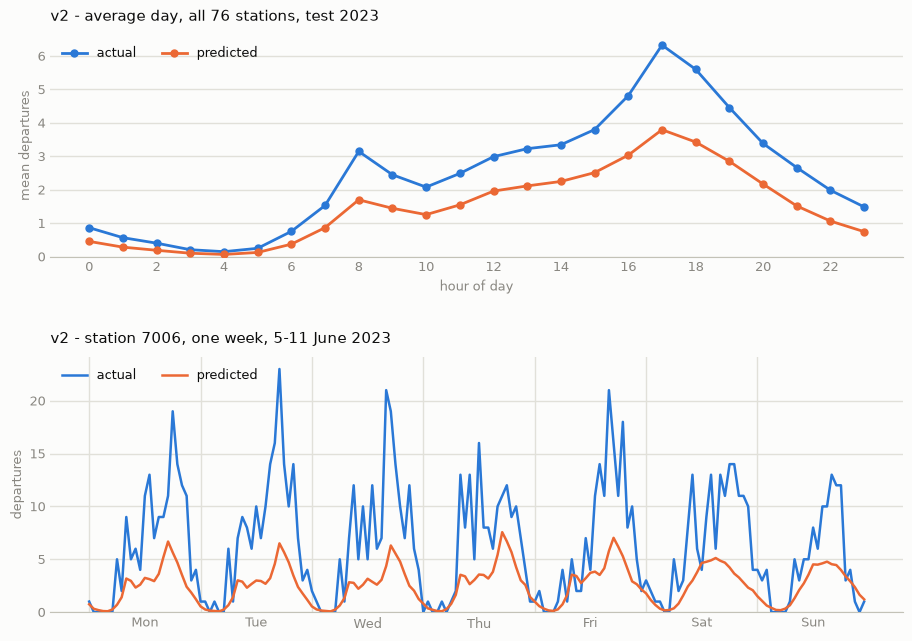

In [30]:
import matplotlib.pyplot as plt

# Validated categorical slots: blue = actual, orange = predicted.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID_C, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 7.5), facecolor=SURFACE,
    gridspec_kw={"height_ratios": [1, 1.15], "hspace": 0.42},
)

ax1.plot(by_hour.index, by_hour[TARGET], color=BLUE, linewidth=2,
         marker="o", markersize=5, label="actual", zorder=3)
ax1.plot(by_hour.index, by_hour["predicted"], color=ORANGE, linewidth=2,
         marker="o", markersize=5, label="predicted", zorder=3)
ax1.set_xticks(range(0, 24, 2))
ax1.set_xlabel("hour of day", fontsize=9, color=MUTED)
ax1.set_ylabel("mean departures", fontsize=9, color=MUTED)
ax1.set_title("v2 - average day, all 76 stations, test 2023",
              fontsize=11, color=INK, loc="left", pad=10)

ax2.plot(week.index, week[TARGET], color=BLUE, linewidth=1.8,
         label="actual", zorder=3)
ax2.plot(week.index, week["predicted"], color=ORANGE, linewidth=1.8,
         label="predicted", zorder=3)

day_starts = range(0, len(week), 24)
for d in day_starts:
    ax2.axvline(d, color=GRID_C, linewidth=1, zorder=1)
ax2.set_xticks(
    [d + 12 for d in day_starts],
    [week.loc[d, "start_date"].strftime("%a") for d in day_starts],
    fontsize=9, color=INK,
)
ax2.set_ylabel("departures", fontsize=9, color=MUTED)
ax2.set_title(f"v2 - station {busiest}, one week, 5-11 June 2023",
              fontsize=11, color=INK, loc="left", pad=10)

for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    ax.yaxis.grid(True, color=GRID_C, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(bottom=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(axis="both", length=0, colors=MUTED, labelsize=9)
    ax.legend(frameon=False, ncols=2, fontsize=9, labelcolor=INK, loc="upper left")

fig.savefig("/tmp/v2-pred-vs-actual.png", dpi=140, facecolor=SURFACE,
            bbox_inches="tight")
plt.show()

In [31]:
# Error by demand level - the band where v1 collapsed.
bands = pd.cut(actual_vs_pred[TARGET], [-0.1, 0, 2, 5, 10, np.inf],
               labels=["0", "1-2", "3-5", "6-10", "11+"])

by_band = actual_vs_pred.groupby(bands, observed=True).apply(
    lambda g: pd.Series({
        "rows": len(g),
        "mean_actual": g[TARGET].mean(),
        "mean_predicted": g["predicted"].mean(),
        "MAE": mean_absolute_error(g[TARGET], g["predicted"]),
    }),
    include_groups=False,
)
by_band["rows"] = by_band["rows"].astype(int)
by_band

,rows,mean_actual,mean_predicted,MAE
trip_count,,,,
0,267079,0.000000,0.533030,0.533030
1-2,179564,1.400787,1.149111,0.923862
3-5,122107,3.816194,2.091037,2.190409
6-10,71037,7.462182,3.326669,4.568054
11+,25973,14.935163,5.925269,9.444999
